# 1D s-wave Superconducting Mean-Field SCF

This notebook shows the minimal spin-singlet s-wave pairing SCF path. The normal Hamiltonian is spinful, the BdG Hamiltonian is rebuilt at each iteration from the current onsite pairing profile `Delta_i`, and the new pairing is obtained from the local singlet anomalous density.

In [5]:
using LinearAlgebra
using Plots
using ITensors
using ITensorMPS

include("../src/TensorBinding.jl")
using .TensorBinding

## 1. Spinful normal chain

Onsite s-wave pairing needs spin. We therefore start from a spinless tight-binding chain and add a spin degree of freedom before entering the superconducting SCF loop.

In [6]:
L = 3
N = 2^L
t = 1.0
mu = 0.0

H_seed = TensorBinding.get_Hamiltonian("chain_1d", t; L=L, scale=4.0)
pos_sites = H_seed.sites

H0 = deepcopy(H_seed)
TensorBinding.add_spin!(H0)

println(H0)


TBHamiltonian | L=3, N=8 +spin, scale=auto, maxlinkdim=3 | geometry: 8 sites, 1D | no Tn cache


## 2. Initial pairing seed

A uniform positive seed is enough for this minimal s-wave example. For spatially varying seeds, pass a function or an MPS as `initial_delta`.

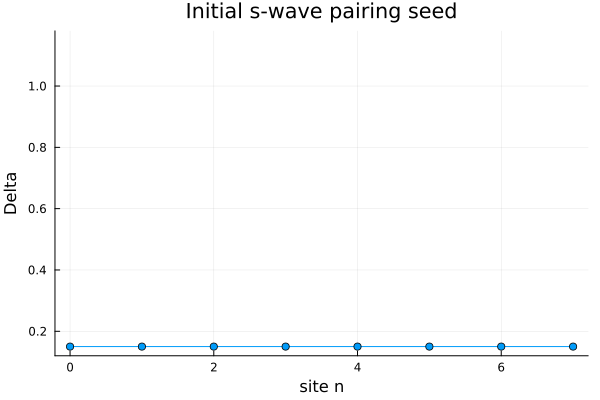

In [7]:
Delta0 = 0.15
Delta0_mps = TensorBinding.scf_profile_mps(
    L,
    pos_sites,
    n -> Delta0;
    type=ComplexF64,
    tol=1e-10,
)

Delta0_vals = [TensorBinding.scf_eval_profile_mps(Delta0_mps, n) for n in 0:N-1]

plot(0:N-1, real.(Delta0_vals);
     marker=:circle,
     xlabel="site n",
     ylabel="Delta",
     title="Initial s-wave pairing seed",
     legend=false)


## 3. Pairing SCF

The update convention is `Delta_new = pairing_sign * g * F_singlet`. With the default `pairing_sign=-1`, positive `g` represents an attractive onsite interaction in the usual BCS sign convention.

In [10]:
g = 1.4

result = TensorBinding.scf_swave_superconducting(
    H0,
    g;
    initial_delta=Delta0_mps,
    pairing_sign=-1.0,
    mu=mu,
    density_method=:mcweeny,
    scale=5,
    max_scf_iter=65,
    purif_maxiter=30,
    purif_tol=1e-5,
    scf_tol=1e-3,
    mix=0.45,
    maxdim=90,
    cutoff=1e-8,
    verbose=true,
)

println("converged = ", result.converged)
println("iterations = ", result.iterations)
println("final RMS = ", result.rms_error)

s-wave SCF iter=1 rms=0.037791459365563475
s-wave SCF iter=2 rms=0.025410935930172466
s-wave SCF iter=3 rms=0.01830758598592985
s-wave SCF iter=4 rms=0.014383666460235658
s-wave SCF iter=5 rms=0.012096148790743177
s-wave SCF iter=6 rms=0.010701310947377666
s-wave SCF iter=7 rms=0.009706577043048685
s-wave SCF iter=8 rms=0.009017716449607523
s-wave SCF iter=9 rms=0.00838036461934315
s-wave SCF iter=10 rms=0.007821261824586692
s-wave SCF iter=11 rms=0.007370754749025363
s-wave SCF iter=12 rms=0.006916720773316351
s-wave SCF iter=13 rms=0.00653720127313021
s-wave SCF iter=14 rms=0.006235850472078049
s-wave SCF iter=15 rms=0.0059181574081181906
s-wave SCF iter=16 rms=0.005622993412153723
s-wave SCF iter=17 rms=0.005353531852677704
s-wave SCF iter=18 rms=0.005085626087194939
s-wave SCF iter=19 rms=0.004852894197188183
s-wave SCF iter=20 rms=0.0046382355787394835
s-wave SCF iter=21 rms=0.004443489395459019
s-wave SCF iter=22 rms=0.004277409463342041
s-wave SCF iter=23 rms=0.00413195885151559

## 4. Pairing profile and convergence

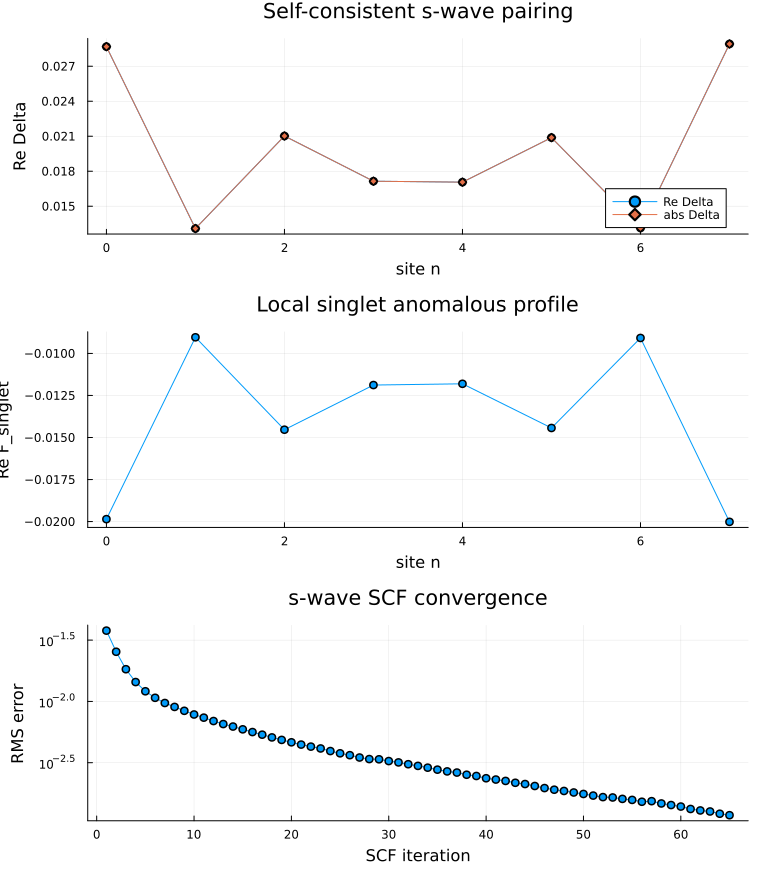

In [11]:
Delta = [TensorBinding.scf_eval_profile_mps(result.delta_mps, n) for n in 0:N-1]
F = [TensorBinding.scf_eval_profile_mps(result.anomalous_mps, n) for n in 0:N-1]
hist_iter = [h.iter for h in result.history]
hist_rms = [h.rms_error for h in result.history]

p1 = plot(0:N-1, real.(Delta);
          marker=:circle,
          xlabel="site n",
          ylabel="Re Delta",
          title="Self-consistent s-wave pairing",
          label="Re Delta")
plot!(p1, 0:N-1, abs.(Delta); marker=:diamond, label="abs Delta")

p2 = plot(0:N-1, real.(F);
          marker=:circle,
          xlabel="site n",
          ylabel="Re F_singlet",
          title="Local singlet anomalous profile",
          legend=false)

p3 = plot(hist_iter, hist_rms;
          yscale=:log10,
          marker=:circle,
          xlabel="SCF iteration",
          ylabel="RMS error",
          title="s-wave SCF convergence",
          legend=false)

plot(p1, p2, p3; layout=(3, 1), size=(760, 880))